In [1]:
import gc
import json
import random
from pathlib import Path

import cv2
import shutil
import time
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet34_Weights, resnet34

In [2]:
DATASET_ROOT = Path("/content/datasets")
IMAGE_ROOT = DATASET_ROOT / "images"
MASK_ROOT = DATASET_ROOT / "crack-seg-semantic" / "masks"

MANIFEST_PATH = Path(
    "/content/"
    "vision_unit_02_outputs/"
    "block_02/"
    "semantic_mask_manifest.csv"
)

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/"
    "vision_unit_02_outputs/"
    "block_03"
)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
IMAGE_SIZE = 416
BATCH_SIZE = 8
NUM_WORKERS = 2
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

USE_AMP = (DEVICE.type == "cuda")
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("AMP:", USE_AMP)
print("Output:", OUTPUT_ROOT)

PyTorch: 2.11.0+cu128
Device: cuda
AMP: True
Output: /content/drive/MyDrive/vision_unit_02_outputs/block_03


**Reproducibility**

In [3]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_everything(SEED)

**Load only train and validation rows**

In [4]:
required_paths = [
    IMAGE_ROOT / "train",
    IMAGE_ROOT / "val",
    MASK_ROOT / "train",
    MASK_ROOT / "val",
    MANIFEST_PATH,
]

for path in required_paths:
    assert path.exists(), (
        f"Missing: {path}"
    )

manifest = pd.read_csv(MANIFEST_PATH)

working_manifest = (
    manifest[manifest["split"].isin(["train", "val"])]
    .copy()
    .reset_index(drop=True)
)

train_frame = (
    working_manifest[working_manifest["split"] == "train"]
    .copy()
    .reset_index(drop=True)
)

val_frame = (
    working_manifest[working_manifest["split"] == "val"]
    .copy()
    .reset_index(drop=True)
)


print("Train:", len(train_frame))
print("Validation:", len(val_frame))
print("Test rows used:",(working_manifest["split"] == "test").sum())


Train: 3717
Validation: 200
Test rows used: 0


**Dataset with synchronized augmentation**

In [ ]:
IMAGENET_MEAN = np.array(
    [0.485, 0.456, 0.406], dtype=np.float32
).reshape(1, 1, 3)

IMAGENET_STD = np.array(
    [0.229, 0.224, 0.225], dtype=np.float32
).reshape(1, 1, 3)

In [31]:
class CrackSemanticDataset(Dataset):
    def __init__(self, frame, image_root, mask_root, image_size=416, augment=False):
        self.frame = frame.reset_index(drop=True).copy()
        self.image_root = Path(image_root)
        self.mask_root = Path(mask_root)
        self.image_size = image_size
        self.augment = augment
    
    def __len__(self):
        return len(self.frame)
    
    def _augment(self, image, mask):
        if random.random() < 0.50:
            image = np.flip(image, axis=1)
            mask = np.flip(mask, axis=1)
            
        if random.random() < 0.50:
            image = np.flip(image, axis=0)
            mask = np.flip(mask, axis=0)
        
        rotation_k = random.randint(0, 3)
        
        if rotation_k:
            image = np.rot90(image, k=rotation_k, axes=(0, 1))
            mask = np.rot90(mask, k=rotation_k, axes=(0, 1))
        
        contrast = random.uniform(0.90, 1.10)
        brightness = random.uniform(-0.05, 0.05)
        
        image = np.clip(
            (image - 0.50) * contrast + 0.50 + brightness,
            0.0, 1.0
        )
        return image, mask
    
    def __getitem__(self, index):
        row = self.frame.iloc[index]
        
        split_name = str(row["split"])
        relative_image = Path(str(row["relative_image"]))
        
        image_path = self.image_root / split_name / relative_image
        
        mask_path = self.mask_root / split_name / relative_image.with_suffix(".png")
        
        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(image_path)

        if mask is None:
            raise FileNotFoundError(mask_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = image.astype(np.float32) / 255.0
        mask = (mask > 0).astype(np.float32)
        
        target_size = (self.image_size, self.image_size)
        
        if image.shape[:2] != target_size:
            image = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)
            
            mask = cv2.resize(mask, target_size, interpolation=cv2.INTER_NEAREST)
        
        if self.augment:
            image, mask = self._augment(image, mask)
        
        image = (image - IMAGENET_MEAN) / IMAGENET_STD
        
        image = np.ascontiguousarray(image.transpose(2, 0, 1))
        mask = np.ascontiguousarray(mask[None, :, :])
        
        return {
            "image": torch.from_numpy(image).float(),
            "mask": torch.from_numpy(mask).float(),
            "relative_image": str(relative_image),
            "crack_ratio": float(row["crack_ratio"]),
        }

**DataLoaders**

In [ ]:
def make_loaders(seed=42):
    train_dataset = (
        CrackSemanticDataset(
            frame=train_frame,
            image_root=IMAGE_ROOT,
            mask_root=MASK_ROOT,
            image_size=IMAGE_SIZE,
            augment=True
        )
    )
    
    val_dataset = (
        CrackSemanticDataset(
            frame=val_frame,
            image_root=IMAGE_ROOT,
            mask_root=MASK_ROOT,
            image_size=IMAGE_SIZE,
            augment=False
        )
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    loader_arguments = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": USE_AMP,
        "worker_init_fn": seed_worker
    }
    
    if NUM_WORKERS > 0:
        loader_arguments["persistent_workers"] = True
        loader_arguments["prefetch_factor"] = 2
        
    train_loader = DataLoader(
        train_dataset, shuffle=True,
        generator=generator, **loader_arguments
    )
    val_loader = DataLoader(
        val_dataset, shuffle=False,
        **loader_arguments
    )
    
    return train_dataset, val_dataset, train_loader, val_loader

In [8]:
train_dataset, val_dataset, train_loader, val_loader = make_loaders(SEED)

In [9]:
validation_batch = next(iter(val_loader))

images = validation_batch["image"]
masks = validation_batch["mask"]

print("Image shape:", images.shape)
print("Mask shape:", masks.shape)
print("Mask values:", torch.unique(masks).tolist())
print("Batch crack ratios:", masks.mean(dim=(1, 2, 3)).tolist())

Image shape: torch.Size([8, 3, 416, 416])
Mask shape: torch.Size([8, 1, 416, 416])
Mask values: [0.0, 1.0]
Batch crack ratios: [0.015024038031697273, 0.016763359308242798, 0.03194919601082802, 0.022703632712364197, 0.013226931914687157, 0.009418915957212448, 0.013446514494717121, 0.011684078723192215]


**Visual batch sanity check**

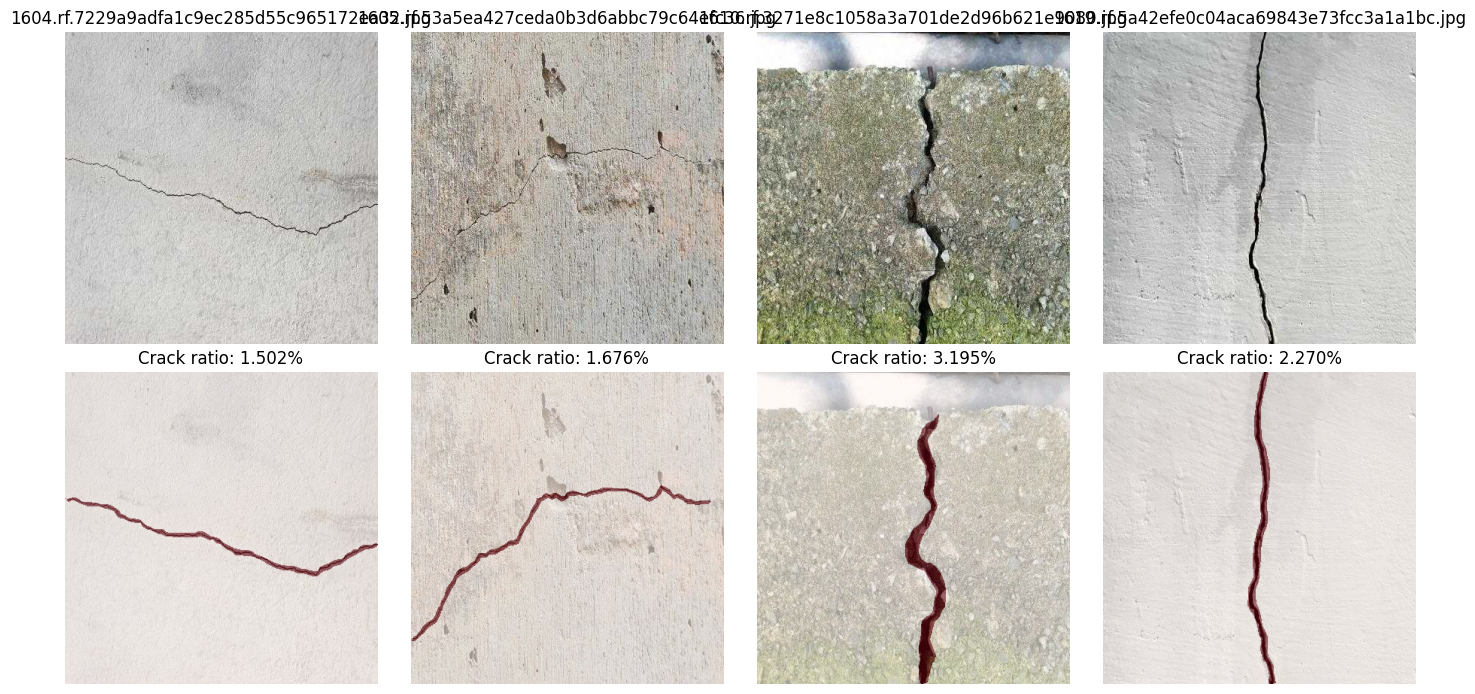

In [10]:
def denormalize_image(image_tensor):
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = image * IMAGENET_STD + IMAGENET_MEAN
    
    return np.clip(image, 0.0, 1.0)


figure, axes = plt.subplots(2, 4, figsize=(14, 7))

for index in range(4):
    image = denormalize_image(images[index])
    mask = masks[index, 0].cpu().numpy()

    axes[0, index].imshow(image)
    axes[0, index].set_title(
        validation_batch["relative_image"][index]
    )

    axes[1, index].imshow(image)
    axes[1, index].imshow(
        mask,
        cmap="Reds",
        alpha=0.55,
        vmin=0,
        vmax=1,
    )

    axes[1, index].set_title(
        f"Crack ratio: "
        f"{mask.mean():.3%}"
    )

    for row in range(2):
        axes[row, index].axis("off")

plt.tight_layout()
sanity_figure_path = (OUTPUT_ROOT / "block_03a_batch_sanity.png")
plt.savefig(sanity_figure_path, dpi=180, bbox_inches="tight",)
plt.show()

### U-Net Model

**Convolution and decoder blocks**

In [11]:
class DoubleConv(nn.Module):
    def __init__(self, input_channels, output_channels):
        super().__init__()
        
        self.block = nn.Sequential(
            nn.Conv2d(
                input_channels, output_channels,
                kernel_size=3, padding=1, bias=False
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True),
            
            nn.Conv2d(output_channels, output_channels,
                      kernel_size=3, padding=1, bias=False
            ),
            nn.BatchNorm2d(output_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.block(x)

In [12]:
class DecoderBlock(nn.Module):
    def __init__(self, input_channels, skip_channels, output_channels):
        super().__init__()
        
        self.convolution = DoubleConv(input_channels + skip_channels, output_channels)
    
    def forward(self, inputs, skip):
        inputs = F.interpolate(
            inputs, size=skip.shape[-2:],
            mode="bilinear", align_corners=False
        )
        combined = torch.cat([inputs, skip], dim=1)
        return self.convolution(combined)

**ResNet34 U-Net**

In [13]:
class ResNet34UNet(nn.Module):
    def __init__(self, weights=None):
        super().__init__()
        
        backbone = resnet34(weights=weights)
        self.stem = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu
        )
        self.pool = backbone.maxpool
        
        self.encoder1 = backbone.layer1
        self.encoder2 = backbone.layer2
        self.encoder3 = backbone.layer3
        self.encoder4 = backbone.layer4
        
        self.decoder_4 = DecoderBlock(
            input_channels=512, skip_channels=256, output_channels=256
        )
        self.decoder_3 = DecoderBlock(
            input_channels=256, skip_channels=128, output_channels=128
        )
        self.decoder_2 = DecoderBlock(
            input_channels=128, skip_channels=64, output_channels=64
        )
        self.decoder_1 = DecoderBlock(
            input_channels=64, skip_channels=64, output_channels=32
        )
        
        self.final_refinement = DoubleConv(
            input_channels=32, output_channels=32
        )
        
        self.segmentation_head = nn.Conv2d(32, 1, kernel_size=1)


    def forward(self, inputs):
        input_size = inputs.shape[-2:]
        
        skip_0 = self.stem(inputs)
        skip_1 = self.encoder1(self.pool(skip_0))
        skip_2 = self.encoder2(skip_1)
        skip_3 = self.encoder3(skip_2)
        
        bottleneck = self.encoder4(skip_3)
        
        decoded = self.decoder_4(bottleneck, skip_3)
        decoded = self.decoder_3(decoded, skip_2)
        decoded = self.decoder_2(decoded, skip_1)
        decoded = self.decoder_1(decoded, skip_0)
        
        decoded = F.interpolate(
            decoded, size=input_size,
            mode="bilinear", align_corners=False
        )
        
        decoded = self.final_refinement(decoded)
        logits = self.segmentation_head(decoded)
        
        return logits

**Forward-pass test**

In [14]:
seed_everything(SEED)

model = ResNet34UNet(
    weights=ResNet34_Weights.DEFAULT
).to(DEVICE)

model.eval()

with torch.inference_mode():
    sample_inputs = images[:2].to(DEVICE, non_blocking=True)
    sample_logits = model(sample_inputs)

parameter_count = sum(parameter.numel() for parameter in model.parameters())
trainable_parameter_count = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

print("Input:", sample_inputs.shape)
print("Logits:", sample_logits.shape)
print("Parameters:", f"{parameter_count:,}")
print("Trainable:",f"{trainable_parameter_count:,}")

assert sample_logits.shape == (
    2, 1,
    IMAGE_SIZE, IMAGE_SIZE,
)
assert torch.isfinite(sample_logits).all()

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 212MB/s]


Input: torch.Size([2, 3, 416, 416])
Logits: torch.Size([2, 1, 416, 416])
Parameters: 24,447,841
Trainable: 24,447,841


### Loss functions

**Dice and BCE + Dice**

In [15]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, logits, targets):
        probabilities = torch.sigmoid(logits)
        dimensions = (1, 2, 3)
        
        intersection = (probabilities * targets).sum(dim=dimensions)
        
        denominator = probabilities.sum(dim=dimensions) + targets.sum(dim=dimensions)
        
        dice_score = (2.0 * intersection + self.smooth) / (denominator + self.smooth)
        
        return (1.00 - dice_score.mean())

In [16]:
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=1.0, dice_weight=1.0):
        super().__init__()
        
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
    
    def forward(self, logits, targets):
        bce_value = self.bce(logits, targets)
        dice_value = self.dice(logits, targets)
        
        return (
            self.bce_weight * bce_value + self.dice_weight * dice_value
        )

In [17]:
criterion = BCEDiceLoss()

sample_targets = masks[:2].to(DEVICE)
sample_loss = criterion(sample_logits, sample_targets)

print( "Initial sample loss:", float(sample_loss))

Initial sample loss: 1.6744436025619507


**Tiny-overfit test**

In [18]:
tiny_dataset = (
    CrackSemanticDataset(
        frame=train_frame.iloc[:4],
        image_root=IMAGE_ROOT,
        mask_root=MASK_ROOT,
        image_size=128,
        augment=False,
    )
)

tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
)

tiny_batch = next(iter(tiny_loader))
tiny_images = tiny_batch["image"].to(DEVICE)
tiny_masks = tiny_batch["mask"].to(DEVICE)


print("Tiny images:", tiny_images.shape)
print("Tiny masks:", tiny_masks.shape)

Tiny images: torch.Size([4, 3, 128, 128])
Tiny masks: torch.Size([4, 1, 128, 128])


**Hard Dice helper**

In [19]:
@torch.no_grad()
def calculate_batch_dice(logits, targets, threshold=0.50, epsilon=1e-7):
    predictions = torch.sigmoid(logits) >= threshold
    targets = targets.bool()
    
    dimensions = (1, 2, 3)
    intersection = (predictions & targets).sum(dim=dimensions).float()
    
    denominator = (
        predictions.sum(dim=dimensions).float() + targets.sum(dim=dimensions).float()
    )
    
    dice = (2.0 * intersection + epsilon) / (denominator + epsilon)
    
    return float(dice.mean())

**Run 60 optimization steps**

In [20]:
seed_everything(SEED)

tiny_model = ResNet34UNet(weights=(ResNet34_Weights.DEFAULT)
).to(DEVICE)

tiny_criterion = BCEDiceLoss()
tiny_optimizer = torch.optim.AdamW(
    tiny_model.parameters(),
    lr=1e-3, weight_decay=1e-4
)
tiny_scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)

TINY_STEPS = 60

tiny_losses = []
tiny_dice_scores = []
tiny_model.train()

for step in range(TINY_STEPS):
    tiny_optimizer.zero_grad(set_to_none=True)
    
    with torch.amp.autocast(
        device_type=DEVICE.type, 
        enabled=USE_AMP
    ):
        logits = tiny_model(tiny_images)
        loss = tiny_criterion(logits, tiny_masks)
    
    tiny_scaler.scale(loss).backward()
    tiny_scaler.unscale_(tiny_optimizer)
    
    torch.nn.utils.clip_grad_norm_(
        tiny_model.parameters(), max_norm=1.0
    )
    
    tiny_scaler.step(tiny_optimizer)
    tiny_scaler.update()
    
    dice = calculate_batch_dice(logits.detach(), tiny_masks)
    
    tiny_losses.append(float(loss.detach()))
    tiny_dice_scores.append(dice)

    if (step == 0 or (step + 1) % 10 == 0):
        print(
            f"Step {step + 1:02d} | "
            f"Loss {tiny_losses[-1]:.4f} | "
            f"Dice {dice:.4f}"
        )

Step 01 | Loss 1.6443 | Dice 0.0772
Step 10 | Loss 1.2604 | Dice 0.5480
Step 20 | Loss 1.1051 | Dice 0.7606
Step 30 | Loss 1.0240 | Dice 0.8132
Step 40 | Loss 0.9605 | Dice 0.8394
Step 50 | Loss 0.9003 | Dice 0.8571
Step 60 | Loss 0.8404 | Dice 0.9041


**Plot tiny-overfit behavior**

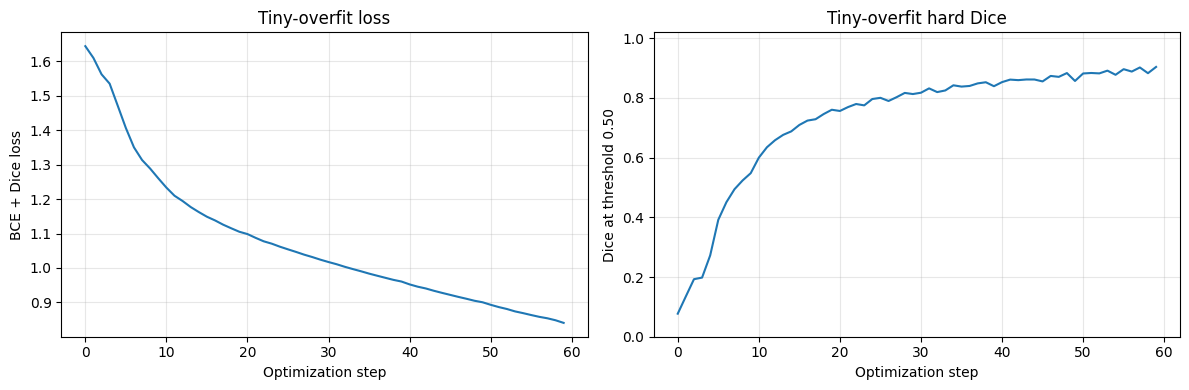

In [21]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tiny_losses)
axes[0].set_title("Tiny-overfit loss")

axes[0].set_xlabel("Optimization step")
axes[0].set_ylabel("BCE + Dice loss")
axes[0].grid(alpha=0.3)

axes[1].plot(tiny_dice_scores)
axes[1].set_title("Tiny-overfit hard Dice")

axes[1].set_xlabel("Optimization step")
axes[1].set_ylabel("Dice at threshold 0.50")

axes[1].set_ylim(0.0, 1.02)
axes[1].grid(alpha=0.3)

plt.tight_layout()
overfit_figure_path = OUTPUT_ROOT/ "block_03a_tiny_overfit.png"

plt.savefig(overfit_figure_path, dpi=180, bbox_inches="tight")
plt.show()

In [22]:
starting_loss = float(np.mean(tiny_losses[:5]))
ending_loss = float(np.mean(tiny_losses[-5:]))

mask_values = sorted(torch.unique(masks).cpu().tolist())

preflight_report = {
    "train_images": len(train_dataset),
    "validation_images": len(val_dataset),
    "test_images_used": 0,
    "image_size": IMAGE_SIZE,
    "input_shape": list(sample_inputs.shape),
    "output_shape": list(sample_logits.shape),
    "mask_values": mask_values,
    "model_parameters": parameter_count,
    "tiny_starting_loss": starting_loss,
    "tiny_ending_loss": ending_loss,
    "tiny_final_dice": float(tiny_dice_scores[-1]),
}

report_path = OUTPUT_ROOT / "block_03a_report.json"
report_path.write_text(json.dumps(preflight_report, indent=2), encoding="utf-8")

assert mask_values == [0.0, 1.0]
assert list(sample_logits.shape) == [2, 1, 416, 416]
assert ending_loss < starting_loss, (
    "Tiny-overfit loss did not decrease. Inspect the pipeline."
)

print("=" * 55)
print("BLOCK 3A — PREFLIGHT PASSED")
print("=" * 55)
print("Starting loss:", round(starting_loss, 4))
print("Ending loss:", round(ending_loss, 4))
print("Final hard Dice:", round(tiny_dice_scores[-1], 4))
print("Report:", report_path)

BLOCK 3A — PREFLIGHT PASSED
Starting loss: 1.5647
Ending loss: 0.8527
Final hard Dice: 0.9041
Report: /content/drive/MyDrive/vision_unit_02_outputs/block_03/block_03a_report.json


**Training configuration**

In [23]:
MAX_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3
BATCH_SIZE = 4

ENCODER_LR = 1e-4
DECODER_LR = 1e-3
WEIGHT_DECAY = 1e-4

GRADIENT_CLIP_NORM = 1.0
RUN_VERSION = "v1"

print("Batch size:", BATCH_SIZE)
print("Maximum epochs:", MAX_EPOCHS)
print("Run version:", RUN_VERSION)

Batch size: 4
Maximum epochs: 10
Run version: v1


**Segmentation metric accumulator**

In [24]:
class BinarySegmentationMeter:
    def __init__(self):
        self.reset()
    
    def reset(self):
        self.tp = 0
        self.fp = 0
        self.fn = 0
        self.tn = 0
    
    @torch.no_grad()
    def update_probabilities(self, probabilities, targets,      threshold=0.50):
        predictions = (probabilities >= threshold)
        targets = (targets >= 0.50)
        
        self.tp += int((predictions & targets).sum())
        self.fp += int((predictions & ~targets).sum())
        
        self.fn += int((~predictions & targets).sum())
        self.tn += int((~predictions & ~targets).sum())
        
    @torch.no_grad()
    def update_logits(self, logits, targets, threshold=0.50):
        probabilities = torch.sigmoid(logits)
        
        self.update_probabilities(probabilities, targets, threshold)
    
    def compute(self):
        def divide(numerator, denominator):
            if denominator == 0:
                return 0.0
            
            return (numerator / denominator)
        
        precision = divide(self.tp, self.tp + self.fp)
        recall = divide(self.tp, self.tp + self.fn)
        
        iou = divide(self.tp, (self.tp + self.fp + self.fn))
        dice = divide(2 * self.tp, ( 2 * self.tp + self.fp + self.fn))
        
        pixel_accuracy = divide(
            self.tp + self.tn, (self.tp + self.fp + self.tn + self.fn)
        )
        
        return {
            "tp": self.tp,
            "fp": self.fp,
            "fn": self.fn,
            "tn": self.tn,
            "precision": precision,
            "recall": recall,
            "iou": iou,
            "dice": dice,
            "pixel_accuracy": (pixel_accuracy)
        }

**One epoch function**

In [25]:
def run_epoch(
    model,
    data_loader,
    criterion,
    device,
    optimizer=None,
    scaler=None,
    threshold=0.50,
):
    is_training = optimizer is not None
    model.train(is_training)

    total_loss = 0.0
    total_examples = 0

    meter = BinarySegmentationMeter()
    progress = tqdm(data_loader, leave=False)

    for batch in progress:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        batch_size = images.shape[0]

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            with torch.amp.autocast(device_type=device.type, enabled=USE_AMP):
                logits = model(images)
                loss = criterion(logits, masks)

            if is_training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), max_norm=GRADIENT_CLIP_NORM
                )
                scaler.step(optimizer)
                scaler.update()

        total_loss += float(loss.detach()) * batch_size
        total_examples += batch_size

        meter.update_logits(logits.detach(), masks, threshold=threshold)
        progress.set_postfix(loss=total_loss / total_examples)

    metrics = meter.compute()
    metrics["loss"] = total_loss / total_examples

    return metrics

**Differential learning rates**

In [26]:
def create_optimizer(model):
    encoder_modules = [
        model.stem,
        model.encoder1, model.encoder2,
        model.encoder3, model.encoder4
    ]
    
    encoder_parameters = [
        parameter for module in encoder_modules
        for parameter in module.parameters()
        if parameter.requires_grad
    ]
    
    encoder_parameters_ids = {
        id(parameter) for parameter in encoder_parameters
    }
    
    decoder_parameters = [
        paramter for paramter in model.parameters()
        if (
            paramter.requires_grad and id(paramter)
            not in encoder_parameters_ids
        )
    ]
    
    optimizer = torch.optim.AdamW([
        {
            "params" : encoder_parameters,
            "lr" : ENCODER_LR
        },
        {
            "params" : decoder_parameters,
            "lr" : DECODER_LR
        },
    ], weight_decay=WEIGHT_DECAY)
    
    return optimizer

**Create one identical initialization**

In [27]:
seed_everything(SEED)

initial_model = ResNet34UNet(
    weights=(ResNet34_Weights.DEFAULT)
)

INITIAL_MODEL_STATE = {
    name: tensor.detach().cpu().clone()
    for name, tensor
    in initial_model.state_dict().items()
}

del initial_model
gc.collect()
print("Identical initial state prepared")

Identical initial state prepared


**Safe checkpoint writer**

In [28]:
def atomic_torch_save(
    payload,
    destination,
):
    destination = Path(destination)
    temporary_path = (destination.parent / f"{destination.name}.tmp")

    torch.save(payload, temporary_path)
    temporary_path.replace(destination)

**Training experiment function**

In [29]:
def train_experiment(
    experiment_name,
    criterion,
):
    experiment_root = OUTPUT_ROOT / f"{RUN_VERSION}_{experiment_name}"
    experiment_root.mkdir(parents=True, exist_ok=True)

    best_path = experiment_root / "best.pt"
    last_path = experiment_root / "last.pt"
    history_path = experiment_root / "history.csv"
    completion_path = experiment_root / "complete.json"

    if completion_path.is_file():
        print(experiment_name, "already complete.")
        return {
            "name": experiment_name,
            "best_path": best_path,
            "history_path": history_path,
        }

    seed_everything(SEED)

    _, _, train_loader, val_loader = make_loaders(SEED)
    
    model = ResNet34UNet(weights=None).to(DEVICE)
    model.load_state_dict(INITIAL_MODEL_STATE)
    optimizer = create_optimizer(model)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max",
        factor=0.50, patience=1,
    )

    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)

    start_epoch = 0
    best_validation_dice = -1.0
    bad_epochs = 0
    history = []

    if last_path.is_file():
        checkpoint = torch.load(
            last_path, map_location=DEVICE, weights_only=False
        )

        model.load_state_dict(checkpoint["model_state"])
        optimizer.load_state_dict(checkpoint["optimizer_state"])
        scheduler.load_state_dict(checkpoint["scheduler_state"])
        scaler.load_state_dict(checkpoint["scaler_state"])

        start_epoch = checkpoint["epoch"] + 1
        best_validation_dice = checkpoint["best_validation_dice"]
        bad_epochs = checkpoint["bad_epochs"]

        if history_path.is_file():
            history = pd.read_csv(history_path).to_dict(orient="records")

        print(f"Resuming {experiment_name} from epoch {start_epoch + 1}")

    start_time = time.perf_counter()

    for epoch in range(start_epoch, MAX_EPOCHS):
        print(f"\n{experiment_name.upper()} | Epoch {epoch + 1}/{MAX_EPOCHS}")

        train_metrics = run_epoch(
            model=model,
            data_loader=train_loader,
            criterion=criterion,
            device=DEVICE,
            optimizer=optimizer,
            scaler=scaler,
            threshold=0.50,
        )

        with torch.inference_mode():
            validation_metrics = run_epoch(
                model=model,
                data_loader=val_loader,
                criterion=criterion,
                device=DEVICE,
                optimizer=None,
                scaler=None,
                threshold=0.50,
            )

        scheduler.step(validation_metrics["dice"])

        history_row = {
            "experiment": experiment_name,
            "epoch": epoch + 1,
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "train_iou": train_metrics["iou"],
            "val_loss": validation_metrics["loss"],
            "val_precision": validation_metrics["precision"],
            "val_recall": validation_metrics["recall"],
            "val_iou": validation_metrics["iou"],
            "val_dice": validation_metrics["dice"],
            "encoder_lr": optimizer.param_groups[0]["lr"],
            "decoder_lr": optimizer.param_groups[1]["lr"],
        }

        history.append(history_row)
        pd.DataFrame(history).to_csv(history_path, index=False)

        current_dice = validation_metrics["dice"]
        improved = current_dice > best_validation_dice

        if improved:
            best_validation_dice = current_dice
            bad_epochs = 0

            atomic_torch_save(
                {
                    "experiment": experiment_name,
                    "epoch": epoch + 1,
                    "model_state": model.state_dict(),
                    "validation_metrics": validation_metrics,
                },
                best_path,
            )
        else:
            bad_epochs += 1

        atomic_torch_save(
            {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "scaler_state": scaler.state_dict(),
                "best_validation_dice": best_validation_dice,
                "bad_epochs": bad_epochs,
            },
            last_path,
        )

        print("Train loss:", round(train_metrics["loss"], 4))
        print(
            f"Validation | Dice {current_dice:.4f} | "
            f"IoU {validation_metrics['iou']:.4f} | "
            f"Precision {validation_metrics['precision']:.4f} | "
            f"Recall {validation_metrics['recall']:.4f}"
        )

        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print("Early stopping.")
            break

    elapsed_minutes = (time.perf_counter() - start_time) / 60.0

    completion_report = {
        "experiment": experiment_name,
        "best_validation_dice_at_0_5": best_validation_dice,
        "training_minutes_this_session": elapsed_minutes,
        "best_checkpoint": str(best_path),
    }

    completion_path.write_text(
        json.dumps(completion_report, indent=2),
        encoding="utf-8",
    )

    del model
    del optimizer
    del scaler

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "name": experiment_name,
        "best_path": best_path,
        "history_path": history_path,
    }

**Train BCE baseline**

In [32]:
bce_result = train_experiment(
    experiment_name="bce", 
    criterion=nn.BCEWithLogitsLoss()
)


BCE | Epoch 1/10


  0%|          | 0/930 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Train loss: 0.0752
Validation | Dice 0.7159 | IoU 0.5575 | Precision 0.8675 | Recall 0.6093

BCE | Epoch 2/10


  0%|          | 0/930 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

Train loss: 0.0255
Validation | Dice 0.7545 | IoU 0.6058 | Precision 0.8359 | Recall 0.6876

BCE | Epoch 5/10


  0%|          | 0/930 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Train loss: 0.0239
Validation | Dice 0.7673 | IoU 0.6224 | Precision 0.7908 | Recall 0.7451
Early stopping.


**Train BCE + Dice**

In [33]:
bce_dice_result = train_experiment(
    experiment_name="bce_dice",
    criterion=BCEDiceLoss(
        bce_weight=1.0, dice_weight=1.0
    )
)


BCE_DICE | Epoch 1/10


  0%|          | 0/930 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Train loss: 0.4906
Validation | Dice 0.7569 | IoU 0.6089 | Precision 0.7916 | Recall 0.7251

BCE_DICE | Epoch 2/10


  0%|          | 0/930 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

Train loss: 0.2731
Validation | Dice 0.7834 | IoU 0.6440 | Precision 0.7694 | Recall 0.7980

BCE_DICE | Epoch 10/10


  0%|          | 0/930 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Train loss: 0.2714
Validation | Dice 0.7665 | IoU 0.6214 | Precision 0.7987 | Recall 0.7368


**Compare training curves**

In [34]:
bce_history = pd.read_csv(bce_result["history_path"])
bce_dice_history = pd.read_csv(bce_dice_result["history_path"])

combined_history = pd.concat(
    [bce_history, bce_dice_history],
    ignore_index=True
)

combined_history_path = OUTPUT_ROOT / "training_history.csv"
combined_history.to_csv(combined_history_path, index=False)

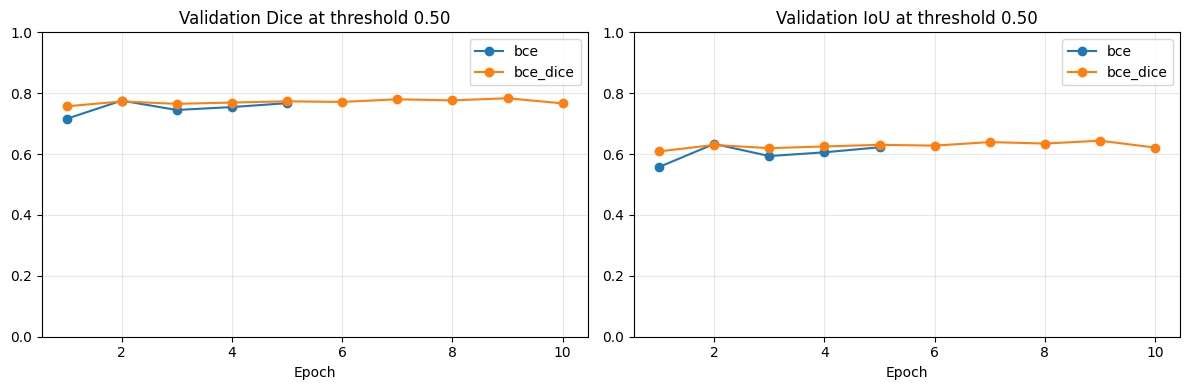

In [35]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

for (experiment_name, experiment_frame) in combined_history.groupby("experiment"):
    axes[0].plot(
        experiment_frame["epoch"],
        experiment_frame["val_dice"],
        marker="o",
        label=experiment_name,
    )

    axes[1].plot(
        experiment_frame["epoch"],
        experiment_frame["val_iou"],
        marker="o",
        label=experiment_name,
    )

axes[0].set_title("Validation Dice at threshold 0.50")
axes[1].set_title("Validation IoU at threshold 0.50")

for axis in axes:
    axis.set_xlabel("Epoch")
    axis.set_ylim(0.0, 1.0)
    axis.grid(alpha=0.3)
    axis.legend()

plt.tight_layout()
training_figure_path = OUTPUT_ROOT / "training_comparison.png"
plt.savefig(
    training_figure_path,
    dpi=180,
    bbox_inches="tight",
)

plt.show()

### Validation threshold selection

**Load best model**

In [36]:
def load_best_model(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path, map_location=DEVICE, weights_only=False
    )
    
    loaded_model = ResNet34UNet(weights=None).to(DEVICE)
    loaded_model.load_state_dict(checkpoint["model_state"])
    loaded_model.eval()

    return loaded_model, checkpoint

**Threshold sweep function**

In [37]:
@torch.inference_mode()
def run_threshold_sweep(model, data_loader, thresholds):
    meters = {
        float(threshold): BinarySegmentationMeter()
        for threshold in thresholds
    }
    
    for batch in tqdm(data_loader, leave=False):
        images = batch["image"].to(DEVICE)
        masks = batch["mask"].to(DEVICE)

        with torch.amp.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            logits = model(images)
        
        probabilities = torch.sigmoid(logits.float())
        for threshold, meter in (meters.items()):
            meter.update_probabilities(
                probabilities,
                masks,
                threshold=threshold,
            )
    
    rows = []
    for threshold, meter in (meters.items()):
        metrics = meter.compute()
        rows.append(
            {
                "threshold": threshold,
                **metrics,
            }
        )

    return pd.DataFrame(rows)

**Sweep both experiments**

In [38]:
THRESHOLDS = np.round(np.arange(0.10, 0.91, 0.05), 2)
_, _, _, threshold_val_loader = make_loaders(SEED)

experiment_results = [bce_result, bce_dice_result]
threshold_frames = []

for result in experiment_results:
    print("Evaluating:", result["name"])

    evaluation_model, checkpoint = load_best_model(result["best_path"])

    sweep_frame = run_threshold_sweep(
        model=evaluation_model,
        data_loader=threshold_val_loader,
        thresholds=THRESHOLDS,
    )

    sweep_frame.insert(0, "experiment", result["name"])
    threshold_frames.append(sweep_frame)

    del evaluation_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

threshold_results = pd.concat(threshold_frames, ignore_index=True)

threshold_results_path = OUTPUT_ROOT / "threshold_sweep.csv"
threshold_results.to_csv(threshold_results_path, index=False) 

Evaluating: bce


  0%|          | 0/50 [00:00<?, ?it/s]

Evaluating: bce_dice


  0%|          | 0/50 [00:00<?, ?it/s]

**Select best threshold and experiment**

In [39]:
summary_rows = []

for experiment_name, experiment_frame in threshold_results.groupby("experiment"):
    best_index = experiment_frame["dice"].idxmax()
    best_row = experiment_frame.loc[best_index]

    summary_rows.append(
        {
            "experiment": experiment_name,
            "best_threshold": float(best_row["threshold"]),
            "precision": float(best_row["precision"]),
            "recall": float(best_row["recall"]),
            "iou": float(best_row["iou"]),
            "dice": float(best_row["dice"]),
            "pixel_accuracy": float(best_row["pixel_accuracy"]),
        }
    )

experiment_summary = (
    pd.DataFrame(summary_rows)
    .sort_values("dice", ascending=False)
    .reset_index(drop=True)
)

display(experiment_summary)
selected_experiment = str(experiment_summary.loc[0, "experiment"])
selected_threshold = float(experiment_summary.loc[0, "best_threshold"])

print("Selected experiment:", selected_experiment)
print("Selected threshold:", selected_threshold)

experiment_summary_path = OUTPUT_ROOT / "experiment_summary.csv"
experiment_summary.to_csv(experiment_summary_path, index=False)

,experiment,best_threshold,precision,recall,iou,dice,pixel_accuracy
0,bce_dice,0.45,0.766564,0.801294,0.644120,0.783544,0.991028
1,bce,0.45,0.745276,0.809394,0.634003,0.776012,0.990531


Selected experiment: bce_dice
Selected threshold: 0.45


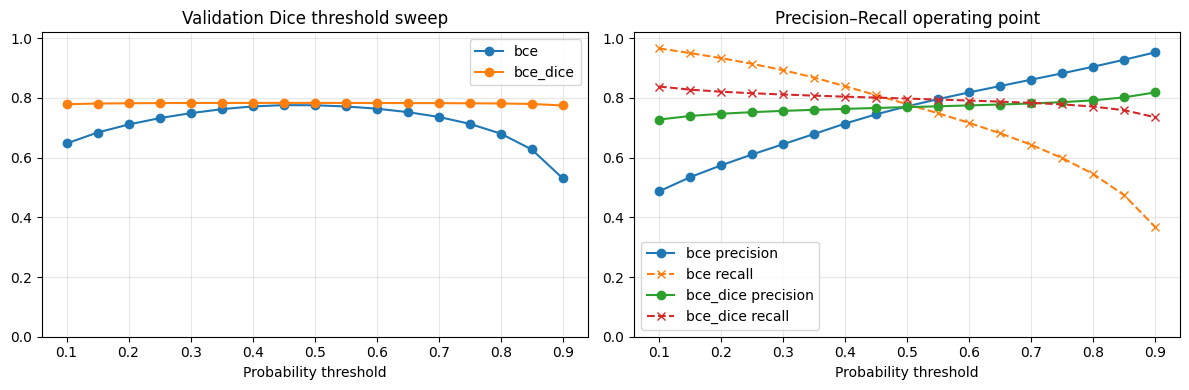

In [40]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

for experiment_name, experiment_frame in threshold_results.groupby("experiment"):
    axes[0].plot(
        experiment_frame["threshold"],
        experiment_frame["dice"],
        marker="o",
        label=experiment_name,
    )

    axes[1].plot(
        experiment_frame["threshold"],
        experiment_frame["precision"],
        marker="o",
        label=f"{experiment_name} precision",
    )

    axes[1].plot(
        experiment_frame["threshold"],
        experiment_frame["recall"],
        marker="x",
        linestyle="--",
        label=f"{experiment_name} recall",
    )

axes[0].set_title("Validation Dice threshold sweep")
axes[1].set_title("Precision–Recall operating point")

for axis in axes:
    axis.set_xlabel("Probability threshold")
    axis.set_ylim(0.0, 1.02)
    axis.grid(alpha=0.3)
    axis.legend()

plt.tight_layout()
threshold_figure_path = OUTPUT_ROOT / "threshold_comparison.png"
plt.savefig(
    threshold_figure_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

In [41]:
selection_report = {
    "selected_experiment": selected_experiment,
    "selected_threshold": selected_threshold,
    "validation_metrics": experiment_summary.iloc[0].to_dict(),
    "test_split_used": False,
}

selection_report_path = OUTPUT_ROOT/ "model_selection_report.json"
selection_report_path.write_text(
    json.dumps(selection_report, indent=2),
    encoding="utf-8",
)

print("Selection report:", selection_report_path)

Selection report: /content/drive/MyDrive/vision_unit_02_outputs/block_03/model_selection_report.json
